<a href="https://colab.research.google.com/github/ajaynunna/Major-project---Online-gaming/blob/main/Onlinegaming.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Topic: Predictive analysis of player engagement and retention.

Dataset : https://www.kaggle.com/datasets/rabieelkharoua/predict-online-gaming-behavior-dataset

Research Question: Can player behavioral metrics predict their Engagement Level (High/Medium/Low), and what are the strongest predictors?

Goal: Develop a classification model to accurately predict player engagement for the purpose of improving retention and optimizing game design.

In [ ]:
# Imports

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)

sns.set(style="whitegrid")


# Load Data

In [ ]:
def load_gaming_dataset(data_path: str):
    """
    Loading the online gaming behavior dataset from a GitHub URL.

    Parameters:
    data_path : str
        Github URL to the dataset CSV file.

    Returns:
    pandas.DataFrame
        Loaded dataset as a pandas DataFrame.

    Description:
    I used this function to load the online gaming behavior dataset
    into a pandas DataFrame so that it can be used for EDA,
    feature engineering, preprocessing, and model training.
    """

    Online_game_data = pd.read_csv(data_path)
    print(" Dataset shape:", Online_game_data.shape)

    return Online_game_data



# Calling Function

DATA_PATH = "https://raw.githubusercontent.com/ajaynunna/Major-project---Online-gaming/refs/heads/main/online_gaming_behavior_dataset.csv"

Online_game_data = load_gaming_dataset(DATA_PATH)

# Displaying first few rows of the dataset
Online_game_data.head()


 Dataset shape: (40034, 13)


,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


# Basic Dataset Inspection

In [ ]:

def inspect_dataset(Online_game_data: pd.DataFrame):
    """
    Basic Dataset Inspection (Info + Summary + Missing Values + Target Distribution)

    Parameters:
    Online_game_data : pd.DataFrame
        The loaded online gaming dataset.

    Returns:
    dict
        A dictionary containing:
        'summary_stats'
        'missing_values'
        'target_distribution'
    """

    print("\n DATASET INFO")
    Online_game_data.info()

    print("\n SUMMARY STATISTICS")

    summary_stats = Online_game_data.describe(include="all").T
    display(summary_stats)

    print("\n MISSING VALUES")

    missing_values = Online_game_data.isna().sum()
    display(missing_values)

    print("\n TARGET DISTRIBUTION (EngagementLevel)")

    target_distribution = Online_game_data["EngagementLevel"].value_counts()
    display(target_distribution)

    return {
        "summary_stats": summary_stats,
        "missing_values": missing_values,
        "target_distribution": target_distribution
    }


# Calling the function
inspection_results = inspect_dataset(Online_game_data)



 DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  object 
 3   Location                   40034 non-null  object 
 4   GameGenre                  40034 non-null  object 
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  int64  
 7   GameDifficulty             40034 non-null  object 
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non-null  int64  
 10  PlayerLevel                40034 non-null  int64  
 11  AchievementsUnlocked       40034 non-null  int64  
 12  EngagementLevel            40034 non-null  object 
dtypes: float64(1), int64(7), object

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PlayerID,40034.0,NaN,NaN,NaN,29016.5,11556.964675,9000.0,19008.25,29016.5,39024.75,49033.0
Age,40034.0,NaN,NaN,NaN,31.992531,10.043227,15.0,23.0,32.0,41.0,49.0
Gender,40034,2,Male,23959,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,40034,4,USA,16000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GameGenre,40034,5,Sports,8048,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PlayTimeHours,40034.0,NaN,NaN,NaN,12.024365,6.914638,0.000115,6.067501,12.008002,17.963831,23.999592
InGamePurchases,40034.0,NaN,NaN,NaN,0.200854,0.400644,0.0,0.0,0.0,0.0,1.0
GameDifficulty,40034,3,Easy,20015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SessionsPerWeek,40034.0,NaN,NaN,NaN,9.471774,5.763667,0.0,4.0,9.0,14.0,19.0
AvgSessionDurationMinutes,40034.0,NaN,NaN,NaN,94.792252,49.011375,10.0,52.0,95.0,137.0,179.0



 MISSING VALUES


,0
PlayerID,0
Age,0
Gender,0
Location,0
GameGenre,0
PlayTimeHours,0
InGamePurchases,0
GameDifficulty,0
SessionsPerWeek,0
AvgSessionDurationMinutes,0



 TARGET DISTRIBUTION (EngagementLevel)


,count
EngagementLevel,
Medium,19374
High,10336
Low,10324


# Exploratory Data Analysis (EDA)

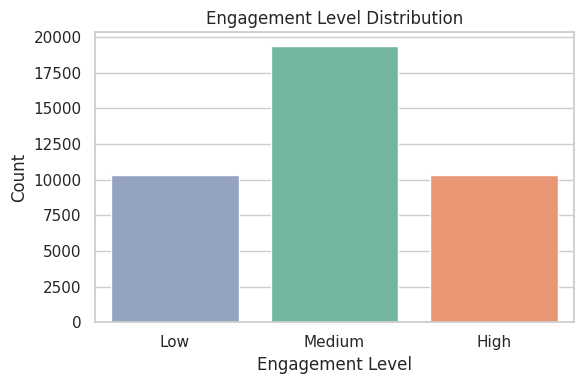


 Engagement Level Counts:
EngagementLevel
Medium    19374
High      10336
Low       10324
Name: count, dtype: int64


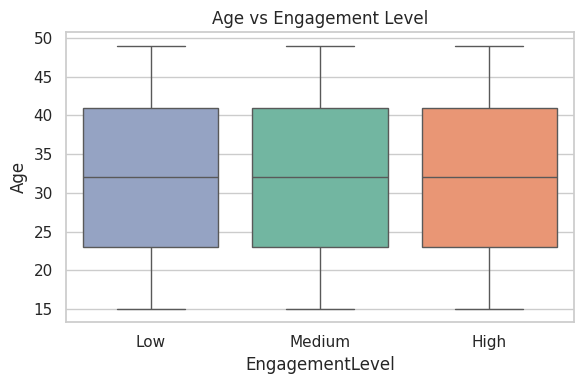

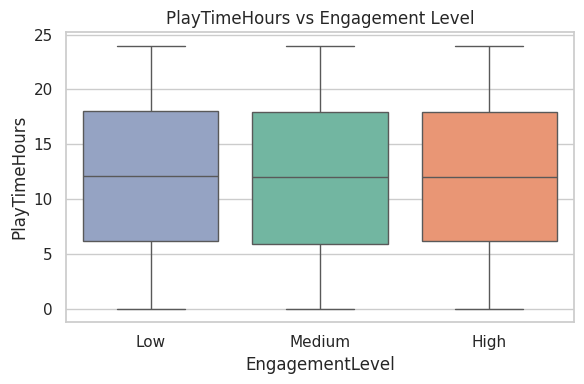

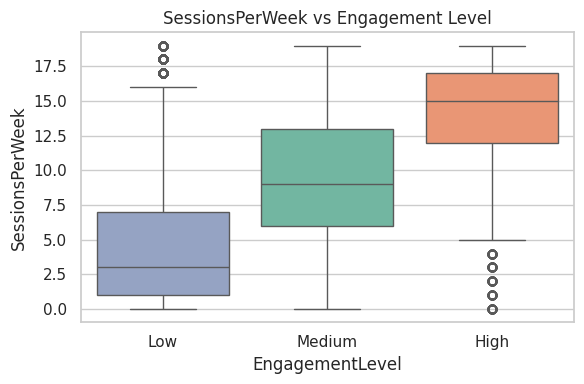

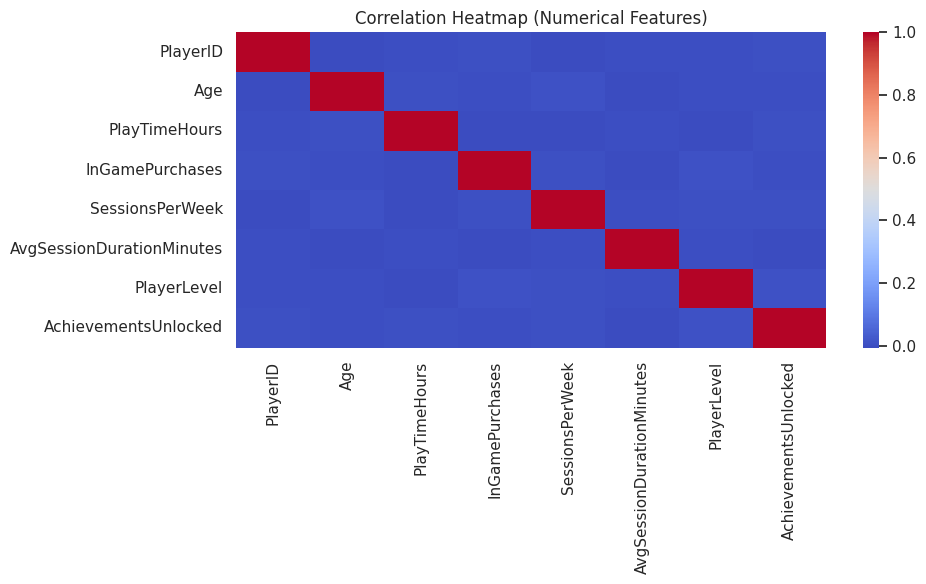

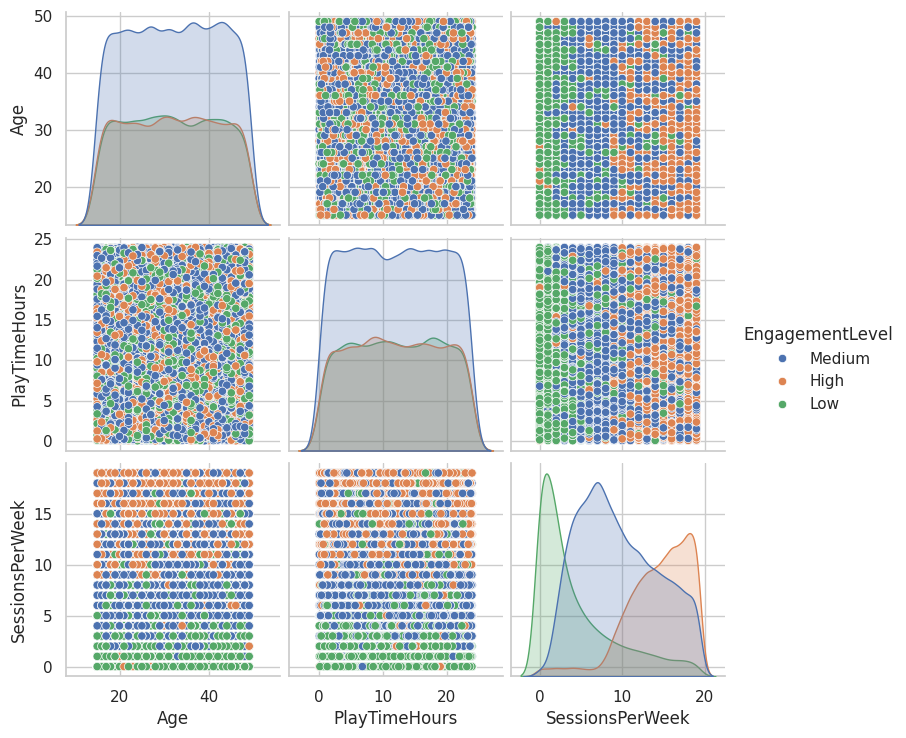

In [ ]:
def eda_plots(Online_game_data: pd.DataFrame):
    """
    Exploratory Data Analysis (EDA)

    What I did:
     I plotted the class distribution of EngagementLevel.
     I compared key numeric features vs engagement using boxplots.
     I checked correlations between numeric features (heatmap).
     I generated a pairplot.

    Parameters:
    Online_game_data : pd.DataFrame
        The gaming dataset.

    Returns:
    None

    """

    #Engagement Level Distribution
    plt.figure(figsize=(6,4))
    sns.countplot(x="EngagementLevel", hue="EngagementLevel", data=Online_game_data, palette="Set2", order=["Low","Medium","High"], legend=False)
    plt.title("Engagement Level Distribution")
    plt.xlabel("Engagement Level")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    print("\n Engagement Level Counts:")
    print(Online_game_data["EngagementLevel"].value_counts())

    #Age vs Engagement
    plt.figure(figsize=(6,4))
    sns.boxplot(x="EngagementLevel", hue="EngagementLevel", y="Age", data=Online_game_data, palette="Set2", order=["Low","Medium","High"], legend=False)
    plt.title("Age vs Engagement Level")
    plt.tight_layout()
    plt.show()

    #PlayTimeHours vs Engagement
    plt.figure(figsize=(6,4))
    sns.boxplot(x="EngagementLevel", y="PlayTimeHours", hue="EngagementLevel", data=Online_game_data, palette="Set2", order=["Low","Medium","High"], legend=False)
    plt.title("PlayTimeHours vs Engagement Level")
    plt.tight_layout()
    plt.show()

    #SessionsPerWeek vs Engagement
    plt.figure(figsize=(6,4))
    sns.boxplot(x="EngagementLevel", y="SessionsPerWeek", hue="EngagementLevel", data=Online_game_data, palette="Set2", order=["Low","Medium","High"])
    plt.title("SessionsPerWeek vs Engagement Level")
    plt.tight_layout()
    plt.show()

    #Correlation Heatmap
    plt.figure(figsize=(10,6))
    corr = Online_game_data.select_dtypes(include=["int64","float64"]).corr()
    sns.heatmap(corr, annot=False, cmap="coolwarm")
    plt.title("Correlation Heatmap (Numerical Features)")
    plt.tight_layout()
    plt.show()

    #Pair Plot for Behavioral Features
    sns.pairplot(
        Online_game_data[['Age', 'PlayTimeHours', 'SessionsPerWeek', 'EngagementLevel']],
        hue="EngagementLevel"
    )
    plt.show()


# Calling Function
eda_plots(Online_game_data)

# Feature Engineering

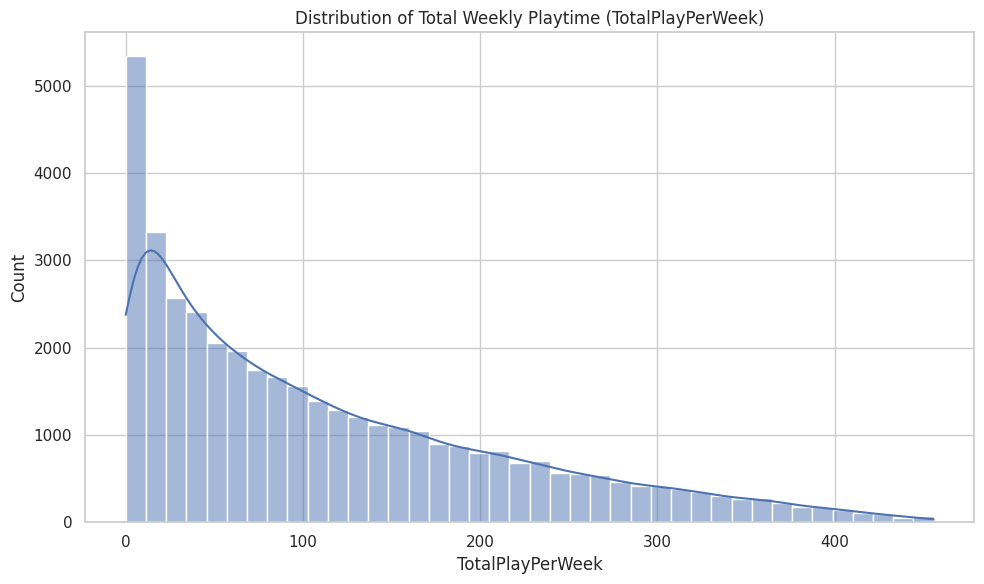

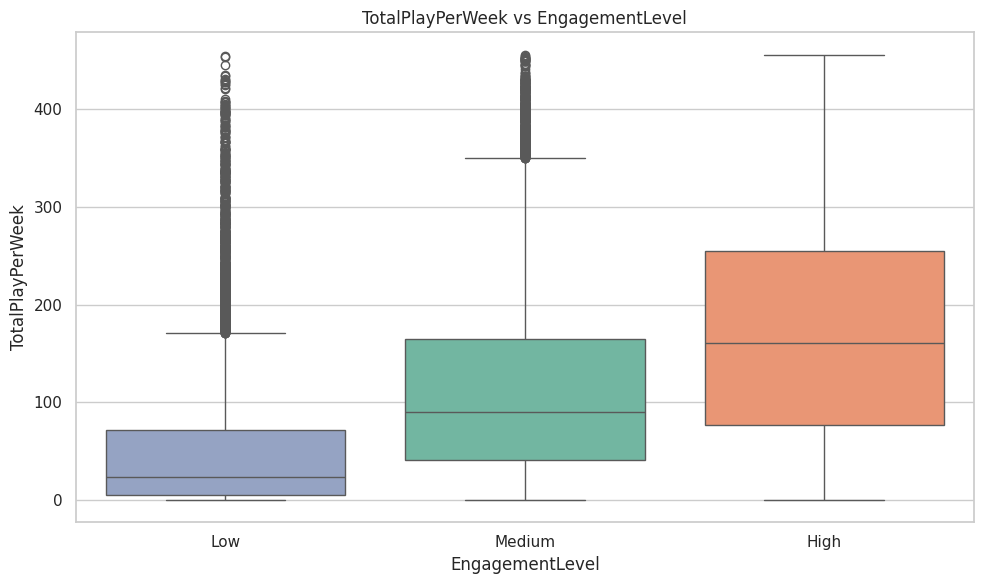

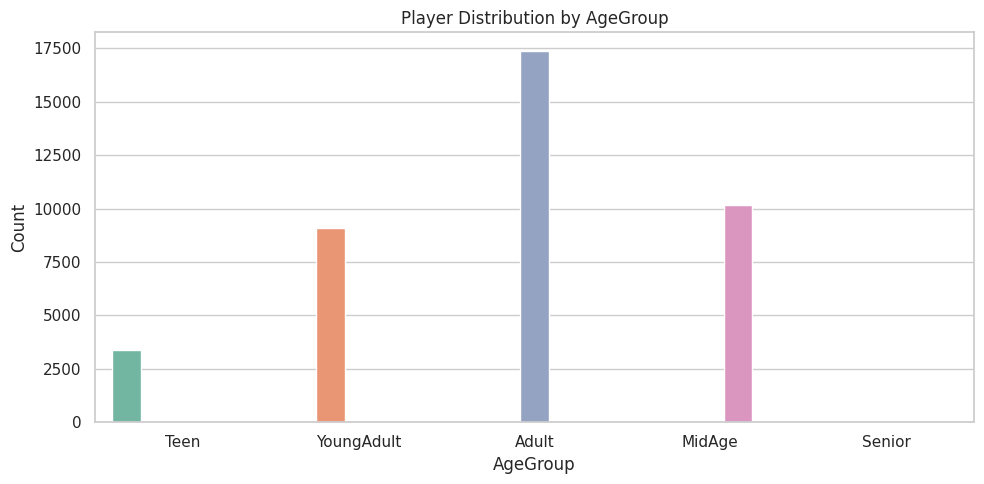

Updated dataset shape: (40034, 15)


,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,TotalPlayPerWeek,AgeGroup
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium,97.626713,MidAge
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium,27.629807,Adult
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High,131.580084,YoungAdult
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium,47.388161,Adult
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium,31.063889,Adult


In [ ]:

def feature_engineering_and_visualization(Online_game_data: pd.DataFrame,
                                          target_col: str = "EngagementLevel"):
    """
    Feature Engineering and Visualization

    What I did:
    I created TotalPlayPerWeek = PlayTimeHours * SessionsPerWeek.
    I created AgeGroup by binning Age into: Teen, YoungAdult, Adult, MidAge, Senior.
    I plotted:
        1) Distribution of TotalPlayPerWeek
        2) TotalPlayPerWeek vs EngagementLevel
        3) Player count by AgeGroup

    Parameters:
    Online_game_data : pd.DataFrame
        The online gaming dataset.
    target_col : str
        Target column name (default: EngagementLevel).

    Returns:
    pd.DataFrame
        A new DataFrame with engineered features added.
    """
    New_Features = Online_game_data.copy()

    #Total weekly playtime
    New_Features["TotalPlayPerWeek"] = New_Features["PlayTimeHours"] * New_Features["SessionsPerWeek"]

    # Age groups
    New_Features["AgeGroup"] = pd.cut(
        New_Features["Age"],
        bins=[0, 17, 25, 40, 60, 100],
        labels=["Teen", "YoungAdult", "Adult", "MidAge", "Senior"]
    )

    sns.set(style="whitegrid")

    # Distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(New_Features["TotalPlayPerWeek"], bins=40, kde=True)
    plt.title("Distribution of Total Weekly Playtime (TotalPlayPerWeek)")
    plt.xlabel("TotalPlayPerWeek")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    # Boxplot vs target
    plt.figure(figsize=(10, 6))
    sns.boxplot(
        x=target_col,
        hue="EngagementLevel",
        y="TotalPlayPerWeek",
        data=New_Features,palette="Set2", legend=False,
        order=["Low", "Medium", "High"]
    )
    plt.title("TotalPlayPerWeek vs EngagementLevel")
    plt.xlabel("EngagementLevel")
    plt.ylabel("TotalPlayPerWeek")
    plt.tight_layout()
    plt.show()

    # AgeGroup counts
    plt.figure(figsize=(10, 5))
    sns.countplot(x="AgeGroup", hue="AgeGroup", data=New_Features, palette="Set2", legend=False)
    plt.title("Player Distribution by AgeGroup")
    plt.xlabel("AgeGroup")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    return New_Features


#CALLING THE FUNCTION
Online_game_data = feature_engineering_and_visualization(Online_game_data, target_col="EngagementLevel")

print("Updated dataset shape:", Online_game_data.shape)
Online_game_data.head()


# Encoding, Scaling & Train-Test Split

In [ ]:

def preprocess_and_split_data(
    Online_game_data: pd.DataFrame,
    target_col: str = "EngagementLevel",
    test_size: float = 0.2,
    random_state: int = 42
):
    """
    Preprocessing: One-Hot Encoding + Scaling + Train/Test Split

    What I did:
    I separated features (X) and target (y).
    I identified numerical and categorical columns.
    I applied One-Hot Encoding to categorical columns.
    I applied StandardScaler to the final encoded matrix.
    I used stratified train-test split to keep class balance same in train and test.

    Returns:
    X_train, X_test, y_train, y_test, final_feature_names, preprocessor, scaler
    """

    # Split X and y
    X = Online_game_data.drop(target_col, axis=1)
    y = Online_game_data[target_col]

    # Identify column types
    numerical_cols = []
    categorical_cols = []

    for col in X.columns:
        try:
            pd.to_numeric(X[col], errors="raise")
            numerical_cols.append(col)
        except:
            categorical_cols.append(col)

    print("Numerical Columns:", numerical_cols)
    print("Categorical Columns:", categorical_cols)

    # One-Hot Encoding
    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
        ],
        remainder="passthrough"
    )

    X_encoded = preprocessor.fit_transform(X)

    # Feature names after encoding
    encoded_feature_names = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_cols)
    final_feature_names = list(encoded_feature_names) + numerical_cols

    print("\nFINAL FEATURE COUNT:", len(final_feature_names))
    print("Feature names:", final_feature_names)

    # Scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_encoded)

    print("\nScaled data shape:", X_scaled.shape)

    # Train/Test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )


    print("TRAIN-TEST SPLIT Data")

    print("Train shape:", X_train.shape)
    print("Test shape:", X_test.shape)

    print("\nTrain target distribution:")
    print(y_train.value_counts())

    print("\nTest target distribution:")
    print(y_test.value_counts())


    #  checks
    if np.isnan(X_train).any() or np.isnan(X_test).any():
        print("\nWARNING: NaN values found in scaled data.")
    if np.isinf(X_train).any() or np.isinf(X_test).any():
        print("\nWARNING: Inf values found in scaled data.")

    return X_train, X_test, y_train, y_test, final_feature_names, preprocessor, scaler


#  Calling function
X_train, X_test, y_train, y_test, feature_names, encoder, scaler = preprocess_and_split_data(
    Online_game_data,
    target_col="EngagementLevel",
    test_size=0.2,
    random_state=42
)


Numerical Columns: ['PlayerID', 'Age', 'PlayTimeHours', 'InGamePurchases', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked', 'TotalPlayPerWeek']
Categorical Columns: ['Gender', 'Location', 'GameGenre', 'GameDifficulty', 'AgeGroup']

FINAL FEATURE COUNT: 27
Feature names: ['Gender_Female', 'Gender_Male', 'Location_Asia', 'Location_Europe', 'Location_Other', 'Location_USA', 'GameGenre_Action', 'GameGenre_RPG', 'GameGenre_Simulation', 'GameGenre_Sports', 'GameGenre_Strategy', 'GameDifficulty_Easy', 'GameDifficulty_Hard', 'GameDifficulty_Medium', 'AgeGroup_Adult', 'AgeGroup_MidAge', 'AgeGroup_Teen', 'AgeGroup_YoungAdult', 'PlayerID', 'Age', 'PlayTimeHours', 'InGamePurchases', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked', 'TotalPlayPerWeek']

Scaled data shape: (40034, 27)
TRAIN-TEST SPLIT Data
Train shape: (32027, 27)
Test shape: (8007, 27)

Train target distribution:
EngagementLevel
Medium    15499
High       82

# Model Training and Evaluation

In [ ]:

def train_and_evaluate_baseline_models(X_train, X_test, y_train, y_test):
    """
    Training baseline classification models and evaluating.

    What I did:
    I trained 5 baseline models on the training set
    I predicted EngagementLevel on the test set
    I printed Accuracy, Classification Report, and Confusion Matrix for each model
    I created a final accuracy comparison table

    Models:
    1) Logistic Regression
    2) Decision Tree
    3) Random Forest
    4) Gradient Boosting
    5) SVM

    Returns:
    baseline_predictions : dict
        Model name - predicted labels on X_test
    baseline_trained_models : dict
        Model name - trained sklearn model object
    baseline_performance_table : pd.DataFrame
        Accuracy table sorted by best accuracy
    """

    baseline_models = {
        "Logistic Regression": LogisticRegression(max_iter=500),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
        "SVM": SVC(kernel="rbf", random_state=42)
    }

    baseline_predictions = {}
    baseline_trained_models = {}
    baseline_accuracy_scores = {}

    for model_name, model in baseline_models.items():
        print(f"\nTraining {model_name}")

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        baseline_predictions[model_name] = y_pred
        baseline_trained_models[model_name] = model

        acc = accuracy_score(y_test, y_pred)
        baseline_accuracy_scores[model_name] = acc

        print(f"Accuracy: {acc:.6f}\n")
        print("Classification Report:\n", classification_report(y_test, y_pred))
        print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
        print("-" * 60)

    baseline_performance_table = (
        pd.DataFrame.from_dict(baseline_accuracy_scores, orient="index", columns=["Accuracy"])
        .sort_values(by="Accuracy", ascending=False)
    )

    print("\nBaseline Model Performance Comparison:")
    print(baseline_performance_table)

    return baseline_predictions, baseline_trained_models, baseline_performance_table


# Calling the function
baseline_predictions, baseline_trained_models, baseline_performance_table = train_and_evaluate_baseline_models(
    X_train, X_test, y_train, y_test
)



Training Logistic Regression
Accuracy: 0.818409

Classification Report:
               precision    recall  f1-score   support

        High       0.89      0.83      0.86      2067
         Low       0.79      0.69      0.74      2065
      Medium       0.80      0.88      0.84      3875

    accuracy                           0.82      8007
   macro avg       0.83      0.80      0.81      8007
weighted avg       0.82      0.82      0.82      8007

Confusion Matrix:
 [[1712   71  284]
 [  58 1435  572]
 [ 161  308 3406]]
------------------------------------------------------------

Training Decision Tree
Accuracy: 0.833770

Classification Report:
               precision    recall  f1-score   support

        High       0.81      0.82      0.81      2067
         Low       0.79      0.81      0.80      2065
      Medium       0.87      0.86      0.86      3875

    accuracy                           0.83      8007
   macro avg       0.82      0.83      0.83      8007
weighted avg    

In [ ]:
def plot_model_results(model_name, y_true, y_pred):
    """
    Plot confusion matrix and Precision/Recall/F1 scores for a model.
    """

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Low", "Medium", "High"],
        yticklabels=["Low", "Medium", "High"]
    )
    plt.title(f"{model_name} – Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    # Precision / Recall / F1
    report = classification_report(y_true, y_pred, output_dict=True)
    scores_df = pd.DataFrame(report).iloc[:3, :3]

    scores_df.plot(
        kind="bar",
        figsize=(8, 4),
        colormap="viridis"
    )
    plt.title(f"{model_name} – Precision, Recall & F1-Score")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


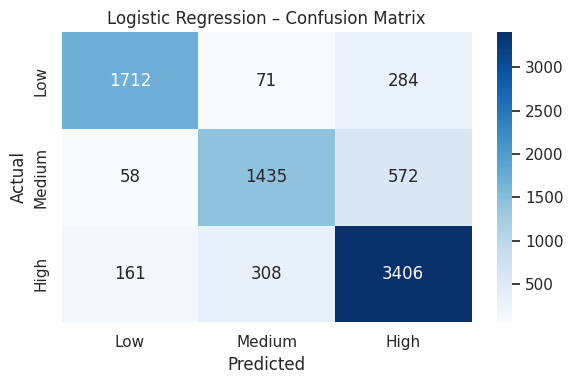

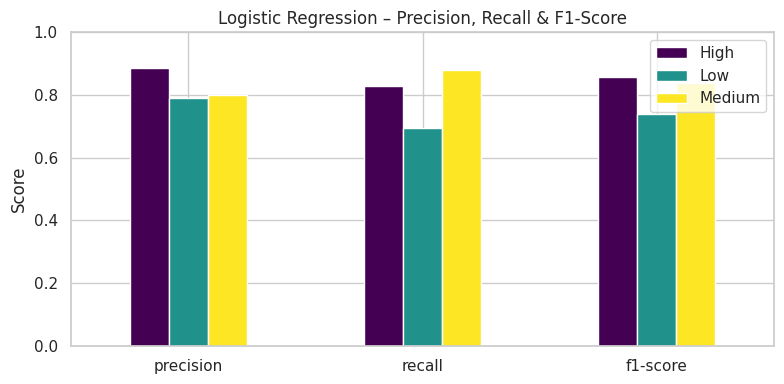

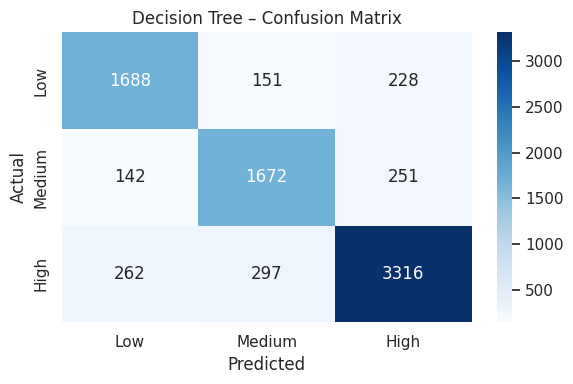

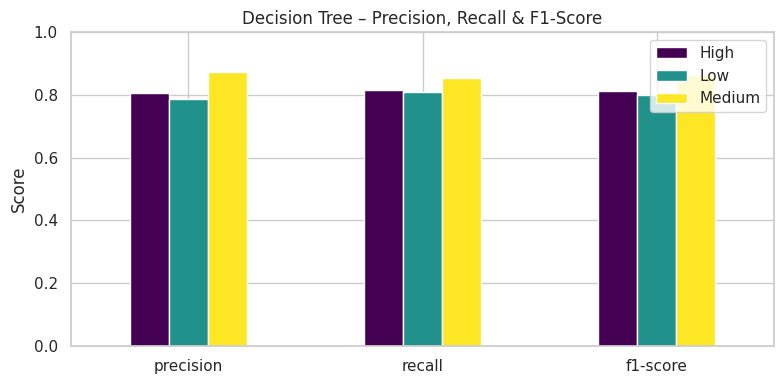

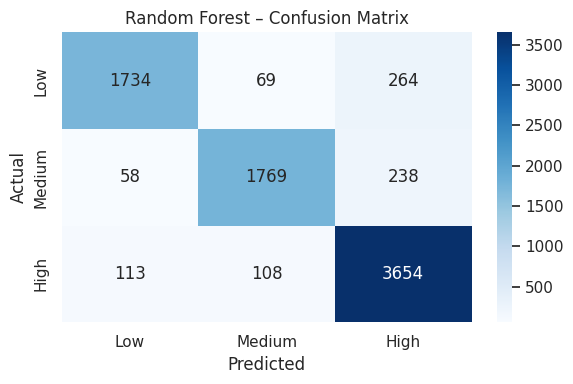

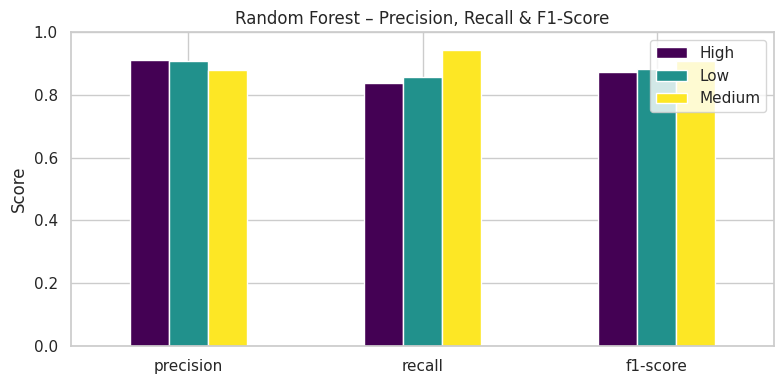

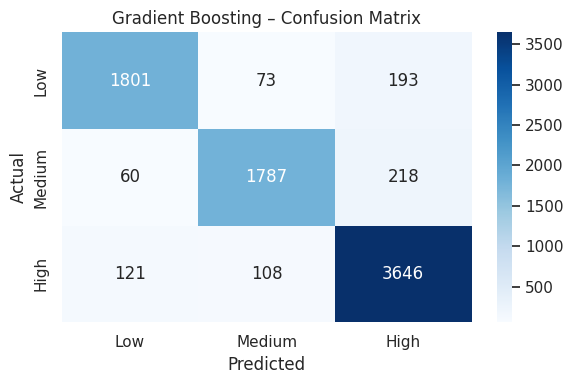

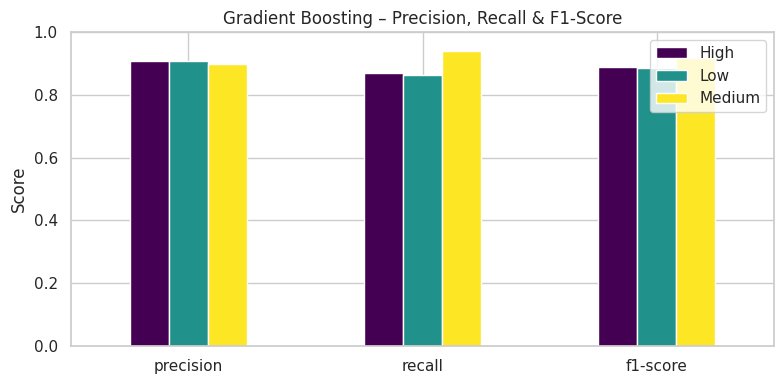

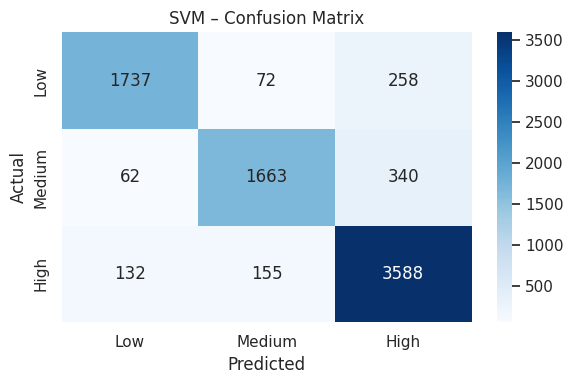

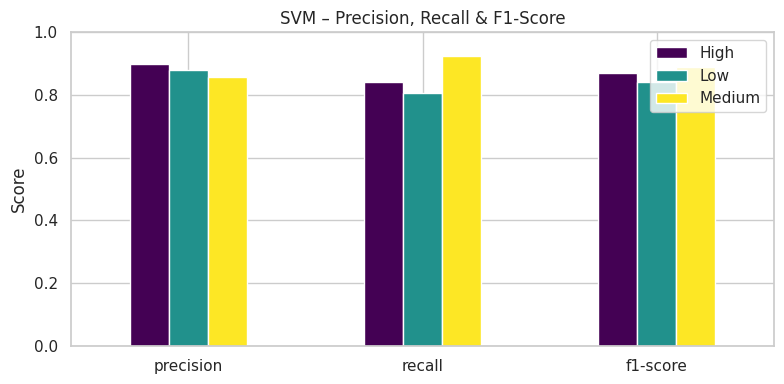

In [ ]:
for model_name, predictions in baseline_predictions.items():
    plot_model_results(
        model_name=model_name,
        y_true=y_test,
        y_pred=predictions
    )

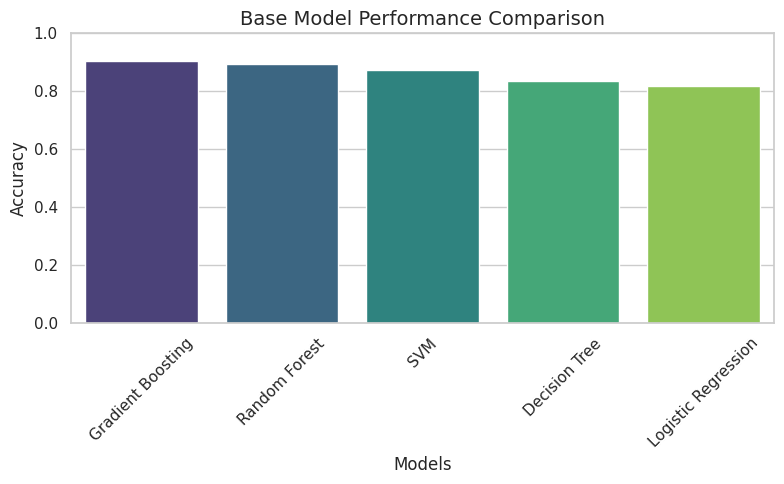

In [ ]:

def plot_base_model_comparison(baseline_performance_table):
    """
    Plot accuracy comparison of baseline models.

    Parameters:
    baseline_performance_table : pd.DataFrame
        DataFrame containing model names and accuracy scores.
    """

    plt.figure(figsize=(8, 5))

    sns.barplot(
        x=baseline_performance_table.index,
        y=baseline_performance_table["Accuracy"],
        hue=baseline_performance_table.index,
        palette="viridis",
        dodge=False,
        legend=False
    )

    plt.title("Base Model Performance Comparison", fontsize=14)
    plt.xlabel("Models")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# CALLING THE FUNCTION
plot_base_model_comparison(baseline_performance_table)


# Hyperparameter Tuning and Evaluation for all 5 Models

In [ ]:
#Hyperparameter Tuning and Evaluation for all 5 Models
def tune_and_evaluate_model(
    model_name: str,
    model,
    param_grid: dict,
    X_train,
    X_test,
    y_train,
    y_test,
    n_iter: int = 5,
    cv: int = 3
):
    """
    Hyperparameter Tuning and Evaluation for a Classification Model

    What I did:
    I applied RandomizedSearchCV to tune model hyperparameters
    I selected the best model based on cross-validation accuracy
    I evaluated performance on the test set
    I visualized results using:
        Confusion Matrix
        Precision / Recall / F1-score bar plot

    Parameters:
    model_name : str
        Name of the model
    model : sklearn estimator
        Base model to be tuned
    param_grid : dict
        Hyperparameter search space
    X_train, X_test, y_train, y_test :
        Train-test split data
    n_iter : int
        Number of random search iterations
    cv : int
        Cross-validation folds

    Returns:
    best_model : sklearn estimator
        Best tuned model
    y_pred : array
        Predictions on test set
    test_accuracy : float
        Accuracy score on test data
    """

    print(f"\n{'='*60}")
    print(f"TUNING MODEL: {model_name}")
    print(f"{'='*60}")

    # Randomized Search
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        n_iter=n_iter,
        cv=cv,
        scoring="accuracy",
        random_state=42,
        n_jobs=-1
    )

    random_search.fit(X_train, y_train)

    best_model = random_search.best_estimator_
    y_pred = best_model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_pred)

    # Results
    print(" Best Parameters:", random_search.best_params_)
    print(" Test Accuracy:", round(test_accuracy, 4))
    print("\n Classification Report:\n")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Low", "Medium", "High"],
        yticklabels=["Low", "Medium", "High"]
    )
    plt.title(f"{model_name} – Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    # Precision / Recall / F1 Plot
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    scores_df = pd.DataFrame(report_dict).iloc[:3, :3]

    scores_df.plot(kind="bar", figsize=(8, 4), colormap="viridis")
    plt.title(f"{model_name} – Precision, Recall & F1-Score")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return best_model, y_pred, test_accuracy



TUNING MODEL: Logistic Regression
 Best Parameters: {'solver': 'liblinear', 'penalty': 'l1', 'C': 0.01}
 Test Accuracy: 0.8244

 Classification Report:

              precision    recall  f1-score   support

        High       0.88      0.84      0.86      2067
         Low       0.80      0.70      0.75      2065
      Medium       0.81      0.88      0.84      3875

    accuracy                           0.82      8007
   macro avg       0.83      0.81      0.82      8007
weighted avg       0.82      0.82      0.82      8007



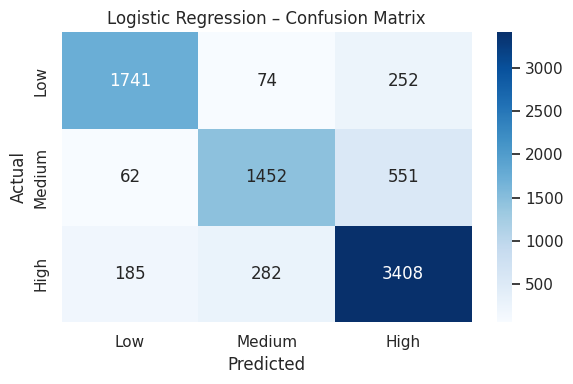

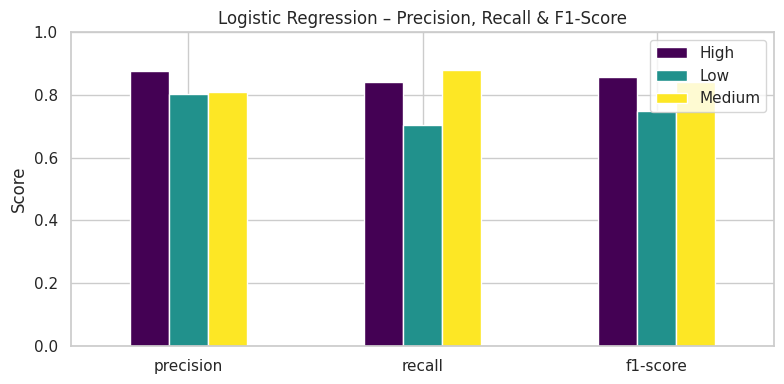

In [ ]:
#Calling function
lr_param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}

best_lr, y_pred_lr, lr_acc = tune_and_evaluate_model(
    model_name="Logistic Regression",
    model=LogisticRegression(max_iter=1000),
    param_grid=lr_param_grid,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)



TUNING MODEL: Logistic Regression
 Best Parameters: {'solver': 'liblinear', 'penalty': 'l1', 'C': 0.01}
 Test Accuracy: 0.8244

 Classification Report:

              precision    recall  f1-score   support

        High       0.88      0.84      0.86      2067
         Low       0.80      0.70      0.75      2065
      Medium       0.81      0.88      0.84      3875

    accuracy                           0.82      8007
   macro avg       0.83      0.81      0.82      8007
weighted avg       0.82      0.82      0.82      8007



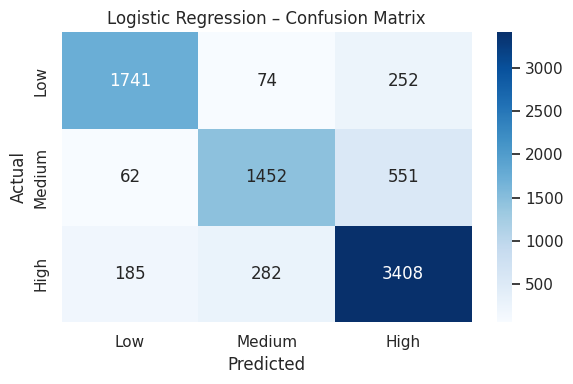

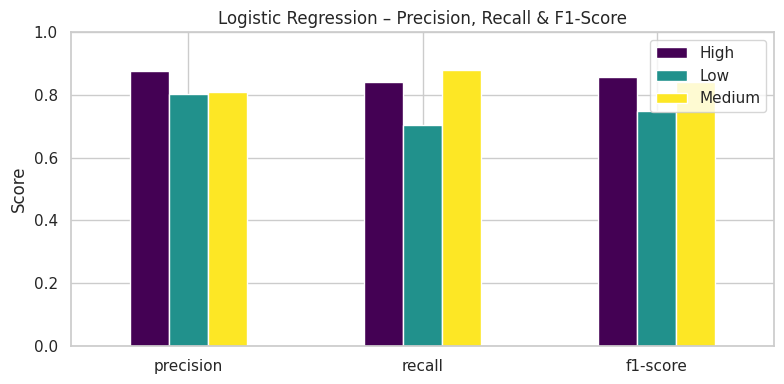

In [ ]:
#Calling function Logistic Regression
lr_param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}

best_lr, y_pred_lr, lr_acc = tune_and_evaluate_model(
    model_name="Logistic Regression",
    model=LogisticRegression(max_iter=1000),
    param_grid=lr_param_grid,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)



TUNING MODEL: Gradient Boosting
 Best Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 5, 'learning_rate': 0.1}
 Test Accuracy: 0.909

 Classification Report:

              precision    recall  f1-score   support

        High       0.91      0.87      0.89      2067
         Low       0.91      0.88      0.90      2065
      Medium       0.91      0.94      0.92      3875

    accuracy                           0.91      8007
   macro avg       0.91      0.90      0.90      8007
weighted avg       0.91      0.91      0.91      8007



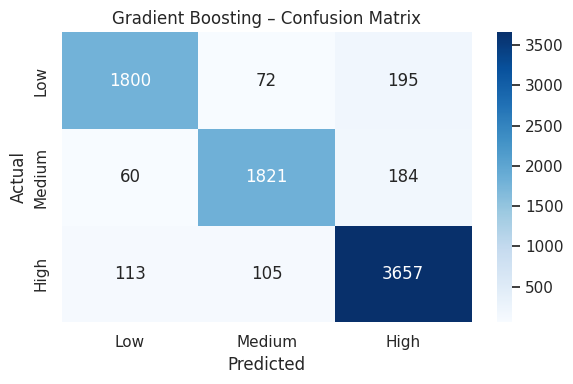

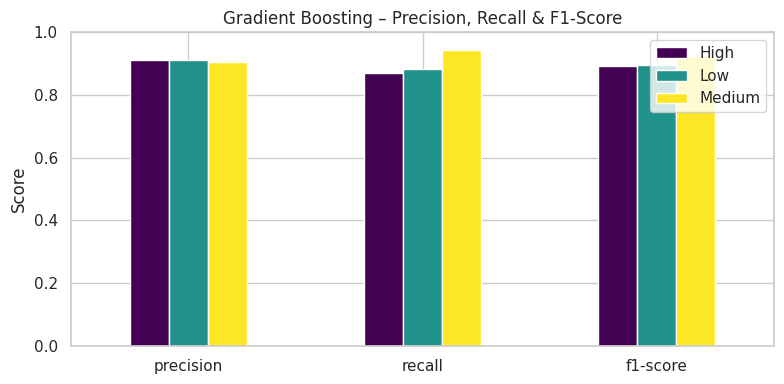

In [ ]:
#Calling function GradientBoostingClassifier
gb_param_grid = {
    "n_estimators": [100, 150],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
    "min_samples_split": [2, 5]
}

best_gb, y_pred_gb, gb_acc = tune_and_evaluate_model(
    model_name="Gradient Boosting",
    model=GradientBoostingClassifier(random_state=42),
    param_grid=gb_param_grid,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)



TUNING MODEL: Random Forest
 Best Parameters: {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
 Test Accuracy: 0.8945

 Classification Report:

              precision    recall  f1-score   support

        High       0.91      0.84      0.87      2067
         Low       0.91      0.86      0.88      2065
      Medium       0.88      0.94      0.91      3875

    accuracy                           0.89      8007
   macro avg       0.90      0.88      0.89      8007
weighted avg       0.90      0.89      0.89      8007



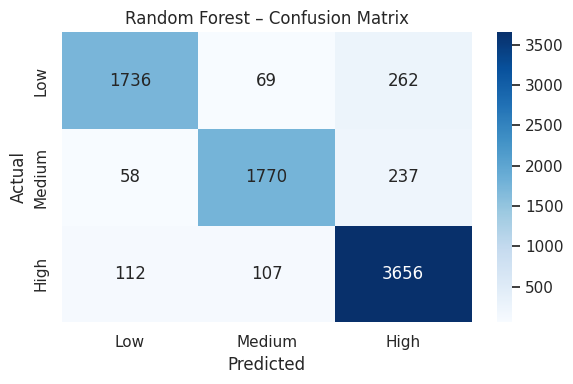

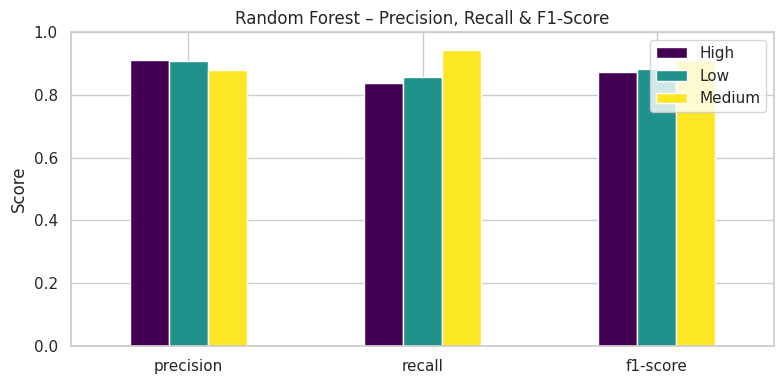

In [ ]:

#Calling function RandomForestClassifier
rf_param_grid = {
    "n_estimators": [100, 150],
    "max_depth": [20, 40],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"]
}

best_rf, y_pred_rf, rf_acc = tune_and_evaluate_model(
    model_name="Random Forest",
    model=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)



TUNING MODEL: SVM
 Best Parameters: {'kernel': 'rbf', 'gamma': 'scale', 'C': 1}
 Test Accuracy: 0.8727

 Classification Report:

              precision    recall  f1-score   support

        High       0.90      0.84      0.87      2067
         Low       0.88      0.81      0.84      2065
      Medium       0.86      0.93      0.89      3875

    accuracy                           0.87      8007
   macro avg       0.88      0.86      0.87      8007
weighted avg       0.87      0.87      0.87      8007



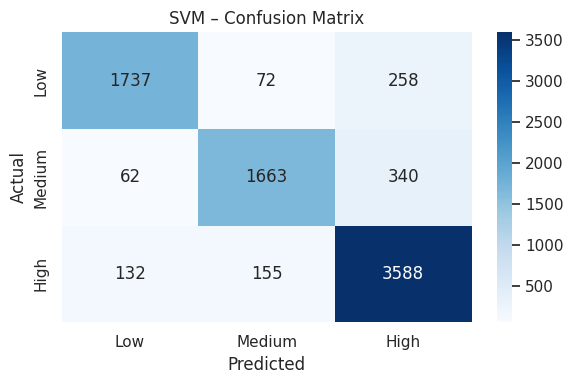

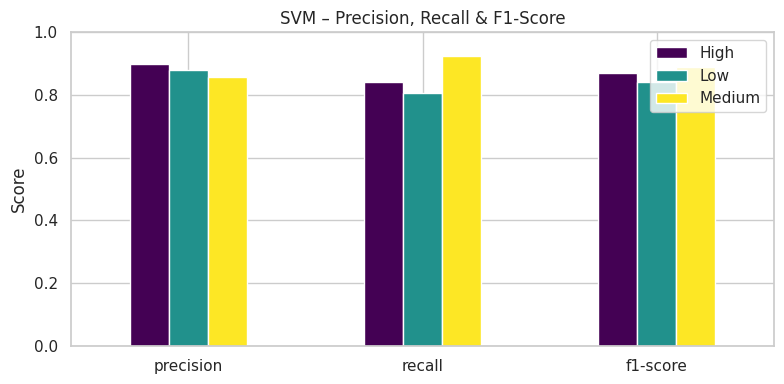

In [ ]:

#Calling function SVM model
svm_param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["rbf"],
    "gamma": ["scale", "auto"]
}

best_svm, y_pred_svm, svm_acc = tune_and_evaluate_model(
    model_name="SVM",
    model=SVC(),
    param_grid=svm_param_grid,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)



TUNING MODEL: Decision Tree
 Best Parameters: {'min_samples_split': 10, 'max_depth': 10, 'criterion': 'gini'}
 Test Accuracy: 0.8941

 Classification Report:

              precision    recall  f1-score   support

        High       0.89      0.87      0.88      2067
         Low       0.88      0.85      0.87      2065
      Medium       0.90      0.93      0.91      3875

    accuracy                           0.89      8007
   macro avg       0.89      0.88      0.89      8007
weighted avg       0.89      0.89      0.89      8007



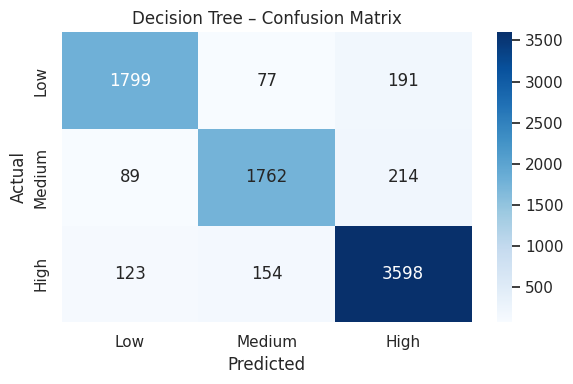

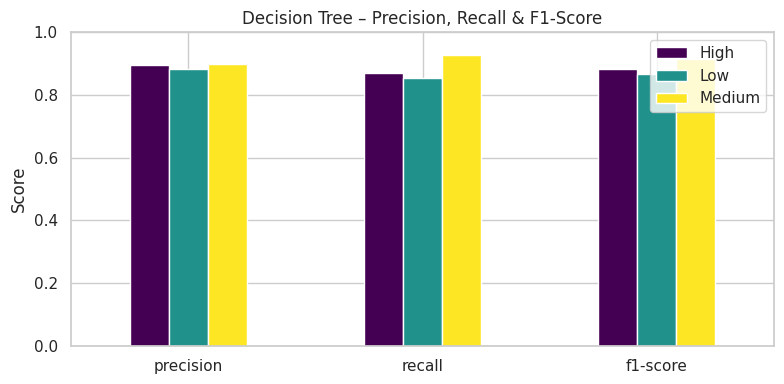

In [ ]:

#Calling function DecisionTreeClassifier
dt_param_grid = {
    "max_depth": [10, 20, 30],
    "min_samples_split": [2, 10, 20],
    "criterion": ["gini", "entropy"]
}

best_dt, y_pred_dt, dt_acc = tune_and_evaluate_model(
    model_name="Decision Tree",
    model=DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)


# feature importance for trained models.

In [ ]:

def plot_feature_importance(
    model,
    model_name: str,
    feature_names: list,
    top_n: int = 15
):
    """
    Plot feature importance for trained models.

    Supports:
     Tree-based models (feature_importances_)
     Logistic Regression (coef_)

    Parameters:
    model : trained sklearn model
    model_name : str
        Name of the model
    feature_names : list
        Feature names after encoding
    top_n : int
        Number of top features to display
    """

    #  Tree-based models
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_

    #  Logistic Regression (multiclass - mean absolute coef)
    elif hasattr(model, "coef_"):
        importances = np.mean(np.abs(model.coef_), axis=0)

    else:
        print(f" Feature importance not supported for {model_name}")
        return

    # Create DataFrame
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False).head(top_n)

    # Plot
    plt.figure(figsize=(8, 5))
    sns.barplot(
        x="Importance",
        y="Feature",
        data=importance_df,
        palette="viridis"
    )
    plt.title(f"{model_name} – Top {top_n} Feature Importance")
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()


/tmp/ipython-input-456442429.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


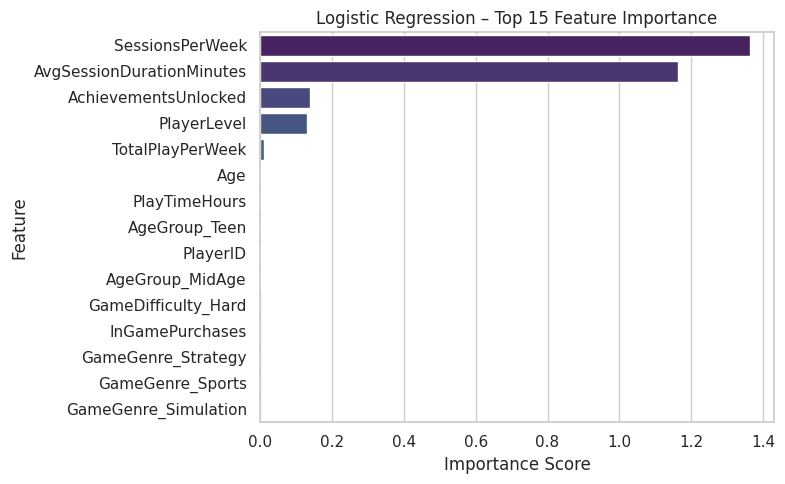

In [ ]:
#calling function for Logistic Regression
plot_feature_importance(
    model=best_lr,
    model_name="Logistic Regression",
    feature_names=feature_names
)


/tmp/ipython-input-456442429.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


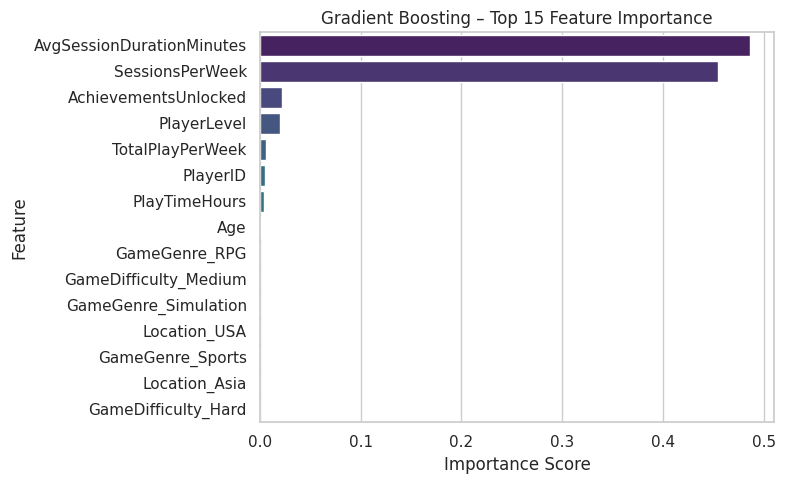

In [ ]:
#calling function for Gradient Boosting
plot_feature_importance(
    model=best_gb,
    model_name="Gradient Boosting",
    feature_names=feature_names
)


/tmp/ipython-input-456442429.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


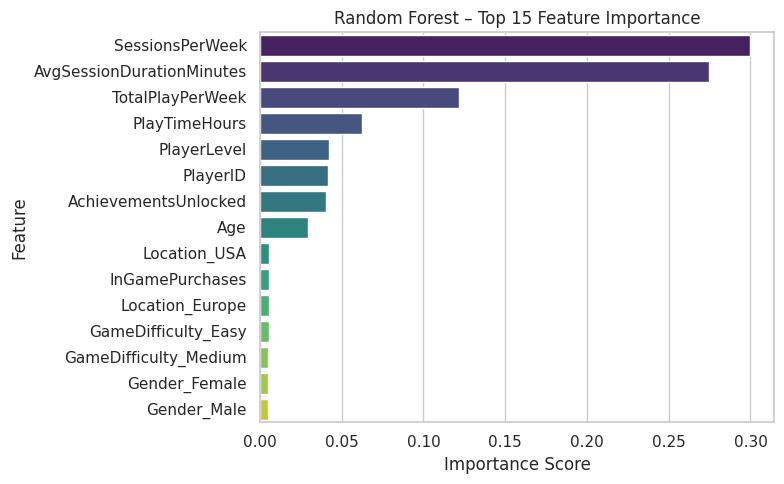

In [ ]:
#calling function for Random Forest
plot_feature_importance(
    model=best_rf,
    model_name="Random Forest",
    feature_names=feature_names
)


/tmp/ipython-input-456442429.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


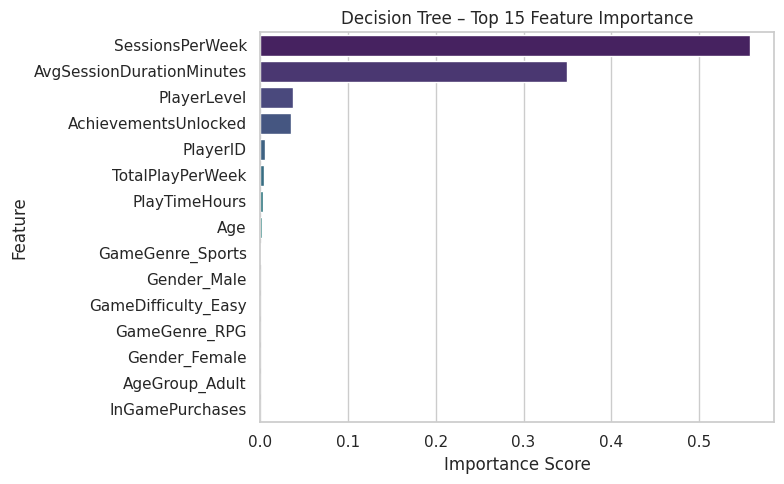

In [ ]:
#calling function for Decision Tree
plot_feature_importance(
    model=best_dt,
    model_name="Decision Tree",
    feature_names=feature_names
)


# Comparing optimized model performances and selecting the best model.

In [ ]:
def compare_optimized_models(
    y_test,
    y_pred_lr,
    y_pred_dt,
    y_pred_rf,
    y_pred_gb,
    y_pred_svm
):
    """
    Compare optimized model performances and select the best model.

    What this function does:
    1. Computes test accuracy for all tuned models.
    2. Displays a sorted performance table.
    3. Plots comparison of optimized model accuracies.
    4. Compares base vs tuned accuracy and calculates improvement (%).
    5. Visualizes improvement after hyperparameter tuning.
    6. Identifies and prints the final best-performing model.

    Parameters:
    y_test : array-like
        True target values.
    y_pred_lr, y_pred_dt, y_pred_rf, y_pred_gb, y_pred_svm : array-like
        Predictions from tuned Logistic Regression, Decision Tree,
        Random Forest, Gradient Boosting, and SVM models.

    Returns:
    pd.DataFrame
        Final comparison table with base accuracy, tuned accuracy,
        and percentage improvement.
    """

    # Optimized accuracy comparison

    optimized_performance = {
        "Logistic Regression": accuracy_score(y_test, y_pred_lr),
        "Decision Tree": accuracy_score(y_test, y_pred_dt),
        "Random Forest": accuracy_score(y_test, y_pred_rf),
        "Gradient Boosting": accuracy_score(y_test, y_pred_gb),
        "SVM": accuracy_score(y_test, y_pred_svm)
    }

    optimized_df = (
        pd.DataFrame.from_dict(
            optimized_performance,
            orient="index",
            columns=["Test Accuracy"]
        )
        .sort_values(by="Test Accuracy", ascending=False)
    )

    print("\n OPTIMIZED MODEL PERFORMANCE \n")
    print(optimized_df)

    # Bar plot for optimized accuracy
    plt.figure(figsize=(8, 5))
    sns.barplot(
        x=optimized_df.index,
        y=optimized_df["Test Accuracy"],
        hue=optimized_df.index,
        palette="viridis",
        legend=False
    )
    plt.title("Comparison of Optimized Model Accuracies")
    plt.ylabel("Test Accuracy")
    plt.xlabel("Models")
    plt.ylim(0, 1)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

    # Base vs Tuned comparison

    final_results = pd.DataFrame({
        "Model": [
            "Logistic Regression",
            "Decision Tree",
            "Random Forest",
            "Gradient Boosting",
            "SVM"
        ],
        "Base Accuracy": [
            0.821406,
            0.828525,
            0.893593,
            0.905333,
            0.879106
        ],
        "Tuned Accuracy": [
            optimized_performance["Logistic Regression"],
            optimized_performance["Decision Tree"],
            optimized_performance["Random Forest"],
            optimized_performance["Gradient Boosting"],
            optimized_performance["SVM"]
        ]
    })

    final_results["Improvement (%)"] = (
        (final_results["Tuned Accuracy"] - final_results["Base Accuracy"]) * 100
    ).round(2)

    print("\n FINAL MODEL COMPARISON\n")
    print(final_results)

    # Improvement plot
    plt.figure(figsize=(9, 5))
    sns.barplot(
        x="Model",
        y="Improvement (%)",
        data=final_results,
        hue="Model",
        palette="viridis",
        legend=False
    )
    plt.title("Accuracy Improvement After Hyperparameter Tuning")
    plt.ylabel("Improvement (%)")
    plt.xlabel("Models")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()


    # Final best model selection

    best_model_row = final_results.loc[
        final_results["Tuned Accuracy"].idxmax()
    ]

    print("\n FINAL MODEL SELECTION \n")
    print(f"FINAL SELECTED MODEL: {best_model_row['Model']}")
    print(f"BEST ACCURACY ACHIEVED: {best_model_row['Tuned Accuracy']:.4f}")

    return final_results



 OPTIMIZED MODEL PERFORMANCE 

                     Test Accuracy
Gradient Boosting         0.908955
Random Forest             0.894467
Decision Tree             0.894093
SVM                       0.872736
Logistic Regression       0.824404


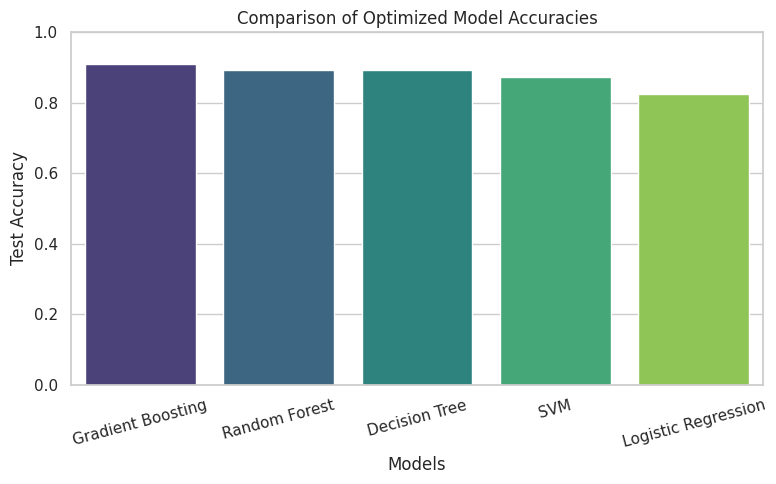


 FINAL MODEL COMPARISON

                 Model  Base Accuracy  Tuned Accuracy  Improvement (%)
0  Logistic Regression       0.821406        0.824404             0.30
1        Decision Tree       0.828525        0.894093             6.56
2        Random Forest       0.893593        0.894467             0.09
3    Gradient Boosting       0.905333        0.908955             0.36
4                  SVM       0.879106        0.872736            -0.64


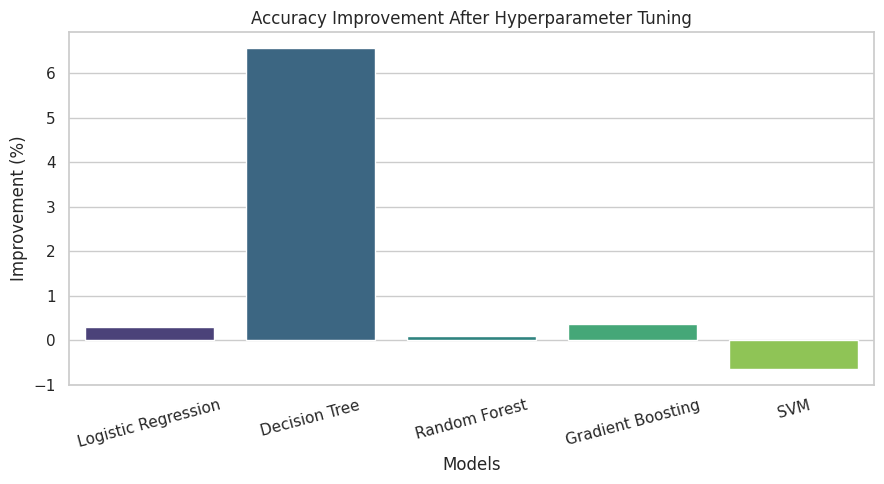


 FINAL MODEL SELECTION 

FINAL SELECTED MODEL: Gradient Boosting
BEST ACCURACY ACHIEVED: 0.9090


In [ ]:
#calling function for final results
final_results = compare_optimized_models(
    y_test,
    y_pred_lr,
    y_pred_dt,
    y_pred_rf,
    y_pred_gb,
    y_pred_svm
)


# Tesing the best model with unseen data
# Predicting engagement level for unseen player data.

In [ ]:
def predict_unseen_player_engagement(
    unseen_player_data: dict,
    trained_model,
    encoder,
    scaler,
    feature_names
):
    """
    Predict engagement level for unseen player data.

    Parameters:
    unseen_player_data : dict
        Dictionary containing player feature values.
    trained_model : sklearn model
        Final trained model - Gradient Boosting.
    encoder : ColumnTransformer
        Fitted preprocessing encoder.
    scaler : StandardScaler
        Fitted scaler.
    feature_names : list
        Final feature names after encoding.

    Returns:
    str
        Predicted Engagement Level.
    """


    # Converting input dictionary to DataFrame
    unseen_df = pd.DataFrame([unseen_player_data])

    # Applying encoding
    unseen_encoded = encoder.transform(unseen_df)

    # Applying scaling
    unseen_scaled = scaler.transform(unseen_encoded)

    # Predict engagement level
    prediction = trained_model.predict(unseen_scaled)[0]

    print(" Unseen Player Input:")
    display(unseen_df)

    print(f" Predicted Engagement Level: **{prediction}**")

    return prediction


In [ ]:
unseen_player = {
    "PlayerID": 99999,
    "Age": 28,
    "Gender": "Male",
    "Location": "USA",
    "GameGenre": "Action",
    "PlayTimeHours": 14.5,
    "InGamePurchases": 1,
    "GameDifficulty": "Medium",
    "SessionsPerWeek": 15,
    "AvgSessionDurationMinutes": 120,
    "PlayerLevel": 55,
    "AchievementsUnlocked": 30,
    "TotalPlayPerWeek": 217.5,
    "AgeGroup": "Adult"
}


In [ ]:
predict_unseen_player_engagement(
    unseen_player_data=unseen_player,
    trained_model=best_gb,
    encoder=encoder,
    scaler=scaler,
    feature_names=feature_names
)


 Unseen Player Input:


,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,TotalPlayPerWeek,AgeGroup
0,99999,28,Male,USA,Action,14.5,1,Medium,15,120,55,30,217.5,Adult


 Predicted Engagement Level: **High**


'High'

In [ ]:


def predict_unseen_player_engagement(
    best_model,
    encoder,
    scaler,
    player_input: dict,
    age_bins=(0, 17, 25, 40, 60, 100),
    age_labels=("Teen", "YoungAdult", "Adult", "MidAge", "Senior")
):
    """
    Unseen Prediction

    What I did:
    I created a single-row DataFrame from unseen player inputs.
    I performed the same feature engineering:
        TotalPlayPerWeek = PlayTimeHours * SessionsPerWeek
        AgeGroup from Age bins
    I applied the SAME fitted encoder + scaler from training.
    I predicted EngagementLevel using the selected best model.

    Parameters:
    best_model : fitted model
    encoder : fitted ColumnTransformer
    scaler : fitted StandardScaler
    player_input : dict
        One unseen player's raw input features

    Returns:
    prediction_label : str
        Predicted engagement label (Low / Medium / High)
    """

    # converted the dict into a 1-row dataframe
    unseen_player_df = pd.DataFrame([player_input])

    # performed feature engineering exactly like training
    unseen_player_df["TotalPlayPerWeek"] = (
        unseen_player_df["PlayTimeHours"] * unseen_player_df["SessionsPerWeek"]
    )

    unseen_player_df["AgeGroup"] = pd.cut(
        unseen_player_df["Age"],
        bins=list(age_bins),
        labels=list(age_labels)
    )

    # applied the same encoder + scaler used in training
    unseen_encoded = encoder.transform(unseen_player_df)
    unseen_scaled = scaler.transform(unseen_encoded)

    # predicted engagement level
    prediction_label = best_model.predict(unseen_scaled)[0]

    print("Unseen Player Input:")
    display(unseen_player_df)
    print(f"\nPredicted Engagement Level: {prediction_label}")

    return prediction_label


# UNSEEN PLAYER EXAMPLE
unseen_player = {
    "PlayerID": 99999,
    "Age": 28,
    "Gender": "Male",
    "Location": "USA",
    "GameGenre": "Action",
    "PlayTimeHours": 14.5,
    "InGamePurchases": 1,
    "GameDifficulty": "Medium",
    "SessionsPerWeek": 15,
    "AvgSessionDurationMinutes": 120,
    "PlayerLevel": 55,
    "AchievementsUnlocked": 30
}

# Calling the function
predicted_label = predict_unseen_player_engagement(
    best_model=best_gb,
    encoder=encoder,
    scaler=scaler,
    player_input=unseen_player
)


Unseen Player Input:


,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,TotalPlayPerWeek,AgeGroup
0,99999,28,Male,USA,Action,14.5,1,Medium,15,120,55,30,217.5,Adult



Predicted Engagement Level: High


I validated the final Gradient Boosting model using a completely unseen player profile.
The input data was processed using the same feature engineering, encoding, and scaling pipeline as the training data.
The model predicted the engagement level as High, which aligns with the player’s high playtime, frequent sessions, and in-game purchases.
This confirms that the model generalizes well and can be used for real-world engagement prediction.